<a href="https://colab.research.google.com/github/me1-3/Emsc2010-A3/blob/main/EMSC2010_A3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project Title:

Dataset used:

- Original -->
  - Name:
  - Source: https://www.bco-dmo.org/dataset/936073
- Cleaned -->
  - Name:
  - Source:

In [6]:
!pip install bambi #system command to install bambi package

In [7]:
# Import required packages for data handling, plotting, modelling, and model comparison

import numpy as np
import matplotlib.pyplot as plt
import bambi as bmb
import arviz as az
import pandas as pd

In [17]:
spreadsheet_name = 'ph.xlsx'
worksheet_name = 'sheet1'

df = pd.read_excel(spreadsheet_name, sheet_name=worksheet_name)

In [19]:
# Clean column names by removing extra spaces, making names uppercase, and replacing spaces with underscores

df.columns = df.columns.str.strip().str.upper().str.replace(' ', '_')

# Display the first few rows to check that the dataset loaded correctly

df.head()

,LOCATION,LAT,LON,SERIAL_NUMBER,ISO_DATETIME_EST,TEMP,PH,PH_FLAG,COND,HDO_MGL,HDO_PERCENTSAT,SALINITY,SALINITY_FLAG,DEPTH,COMMENTS,ISO_DATETIME_UTC
0,Mumford Cove,41.325261,-72.02088,3151819,2015-04-14T14:30,10.30,8.31,NaN,43860.0,11.23,118.4,28.16,NaN,NaN,NaN,2015-04-14T18:30Z
1,Mumford Cove,41.325261,-72.02088,3151819,2015-04-14T15:00,10.95,8.36,NaN,43880.0,12.17,130.1,28.21,NaN,NaN,NaN,2015-04-14T19:00Z
2,Mumford Cove,41.325261,-72.02088,3151819,2015-04-14T15:30,10.36,8.34,NaN,43890.0,12.12,127.9,28.18,NaN,NaN,NaN,2015-04-14T19:30Z
3,Mumford Cove,41.325261,-72.02088,3151819,2015-04-14T16:00,8.85,8.30,NaN,44500.0,11.78,120.4,28.53,NaN,NaN,NaN,2015-04-14T20:00Z
4,Mumford Cove,41.325261,-72.02088,3151819,2015-04-14T16:30,8.45,8.30,NaN,44800.0,11.98,121.6,28.71,NaN,NaN,NaN,2015-04-14T20:30Z


In [23]:
df['ISO_DATETIME_UTC_YEAR'] = pd.to_datetime(df['ISO_DATETIME_UTC']).dt.year

#SELECT EARLY YEAR GROUPS FROM THE DATASET

data_early = df[(df["ISO_DATETIME_UTC_YEAR"] <= 2020)]["PH"].dropna()
data_early = data_early[data_early>0]
data_early = np.log10(data_early)

#SELECT RECENT YEAR GROUPS FROM THE DATASET
data_recent = df[(df["ISO_DATETIME_UTC_YEAR"] >= 2020)]["PH"].dropna()
data_recent = data_recent[data_recent>0]
data_recent = np.log10(data_recent)

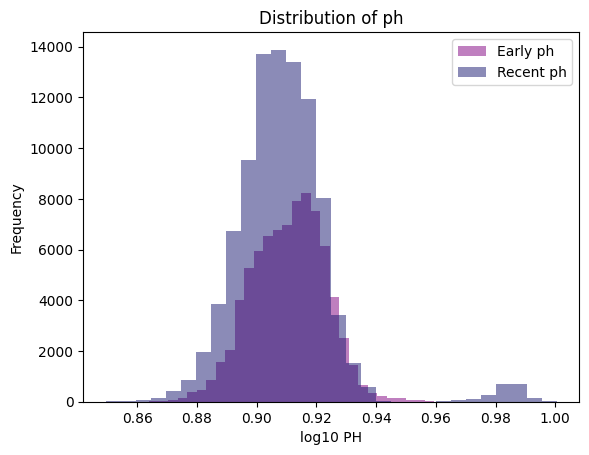

In [24]:

#PLOT HISTOGRAMS TO VISUALISE DISTRIBUTION OF CATCH FOR EACH GROUP
plt.hist(data_early, bins=30, alpha=0.5, color='purple', label='Early (<=2020)')
plt.hist(data_recent, bins=30, alpha=0.5, color='midnightblue', label='Recent (>=2020)')

#LABELS
plt.xlabel("log10 PH")
plt.ylabel("Frequency")
plt.title("Distribution of ph")
plt.legend(["Early ph", "Recent ph"])

#SHOW
plt.show() #show plot